# Install Library

In [ ]:
!pip install -q huggingface_hub transformers torch torchvision gradio pillow numpy

# Image preprocessing and Segmentation

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Please upload your image:


Saving WhatsApp Image 2026-07-04 at 1.09.11 PM.png to WhatsApp Image 2026-07-04 at 1.09.11 PM (4).png


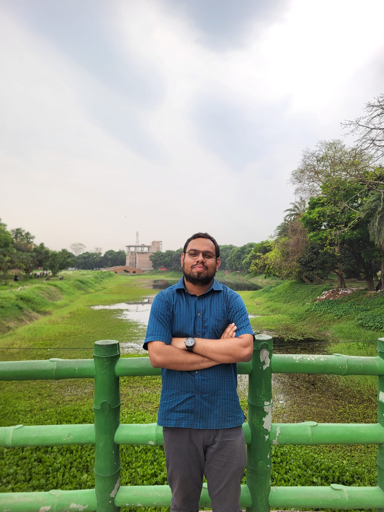

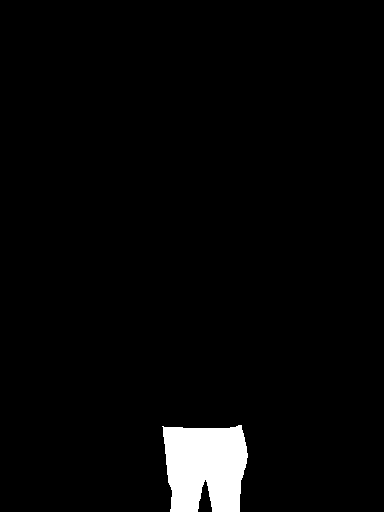

In [ ]:
from google.colab import files
from PIL import Image
import io
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
import torch
import torch.nn as nn
import numpy as np

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

def preprocess_image(image_bytes, max_size=(512, 512)):
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img.thumbnail(max_size)
    return img

def generate_mask(image, clothing_type="Upper body"):
    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu()
    upsampled_logits = nn.functional.interpolate(
        logits,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False,
    )

    pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()
    mask = np.zeros_like(pred_seg, dtype=np.uint8)

    if clothing_type == "Upper body":
        mask[pred_seg == 4] = 255
    elif clothing_type == "Lower body":
        mask[pred_seg == 6] = 255
        mask[pred_seg == 5] = 255

    return Image.fromarray(mask).convert("L")

print("Please upload your image:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    original_image = preprocess_image(uploaded[filename])
    display(original_image)

    clothing_mask = generate_mask(original_image, clothing_type="Lower body")
    display(clothing_mask)

# Inpainting

Sending inpainting request... please wait.
Image generated successfully! Output is shown below:


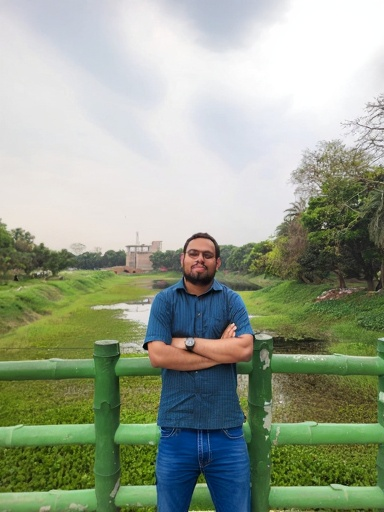

In [ ]:
import base64
from huggingface_hub import InferenceClient
import io
from IPython.display import display


client = InferenceClient(
    provider="fal-ai",
    api_key="Give your hugging face api key",
)


def apply_virtual_tryon(original_img, mask_img, prompt_text):
    def pil_to_base64(img):
        buffered = io.BytesIO()
        img.save(buffered, format="PNG")
        img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
        return f"data:image/png;base64,{img_str}"


    input_image_b64 = pil_to_base64(original_img)
    input_mask_b64 = pil_to_base64(mask_img)


    output_image = client.image_to_image(
        input_image_b64,
        mask_image=input_mask_b64,
        prompt=prompt_text,
        model="black-forest-labs/FLUX.1-Kontext-dev",
    )
    return output_image

# ---------------------------------------------------------
# Test & Display
# ---------------------------------------------------------

test_prompt = "a stylish blue jeans"
print("Sending inpainting request... please wait.")

try:
    final_image = apply_virtual_tryon(original_image, clothing_mask, test_prompt)
    print("Image generated successfully! Output is shown below:")


    display(final_image)

except Exception as e:
    print(f"An error occurred while running the code: {e}")

# UI

In [ ]:
import gradio as gr

def try_on_pipeline(uploaded_file, body_selection, user_prompt):
    if uploaded_file is None:
        return None, None

    img = uploaded_file.convert("RGB")
    img.thumbnail((512, 512))

    mask = generate_mask(img, clothing_type=body_selection)

    try:
        final_img = apply_virtual_tryon(img, mask, user_prompt)
        return mask, final_img
    except Exception as e:
        print(e)
        return mask, None

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# AI Virtual Try-On System")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="pil", label="Upload Image")
            selection = gr.Radio(["Upper body", "Lower body"], label="Select Part", value="Upper body")
            prompt = gr.Textbox(label="Prompt", value="a stylish blue formal shirt")
            btn = gr.Button("Try On", variant="primary")

        with gr.Column():
            mask_preview = gr.Image(label="Mask")
            result_preview = gr.Image(label="Final Result")

    btn.click(
        fn=try_on_pipeline,
        inputs=[input_img, selection, prompt],
        outputs=[mask_preview, result_preview]
    )

demo.launch(debug=True, share=True)

/tmp/ipykernel_1227/2589603181.py:19: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3be89dcd9f3535219a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3be89dcd9f3535219a.gradio.live


### Project Approach & Methodology

This project implements an end-to-end **AI Virtual Try-On system** utilizing a two-step pipeline: semantic segmentation followed by generative AI inpainting. The workflow is designed to be interactive, scalable, and highly accurate.

**1. Semantic Segmentation (Mask Generation)**
To accurately isolate the clothing from the person, we utilized the pretrained `mattmdjaga/segformer_b2_clothes` model. This Transformer-based architecture processes the input image and creates a highly precise binary mask of the targeted region (upper body or lower body). This ensures that only the clothing is modified while the user's face, hands, and background remain completely intact.

**2. Generative Inpainting (Garment Replacement)**
For the generative phase, we integrated the powerful `black-forest-labs/FLUX.1-Kontext-dev` model via the Hugging Face Inference API. The original image and the generated segmentation mask were encoded into Base64 format (to ensure JSON payload compatibility) and sent to the API along with a user-defined text prompt. The model uses this prompt to seamlessly render the new garment inside the masked area, accurately matching the lighting, posture, and shadows of the original image.

**3. Interactive Deployment**
Finally, the entire backend pipeline was wrapped in a **Gradio** web interface. This provides a user-friendly UI where individuals can upload their photos, select the target body part, input their desired clothing description, and view the real-time try-on results side-by-side.